In [47]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitGaussian2D
import os
import matplotlib.pyplot as plt
import referenceFrames as rf
import numpy as np
import math
import tables
import scipy.constants as constants

In [48]:
sim = Simulation("PSF")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# One full-frame exposure

sim["ObservingParameters/NumExposures"] = 1
sim["CCD/IncludeConvolution"] = "yes"

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

dim = 10
sim["SubField/NumRows"] = dim
sim["SubField/NumColumns"] = dim

sim["ControlHDF5Content/WriteSubPixelImages"] = "yes"
sim["SubField/SubPixels"] = 128
numSubPixels = sim["SubField/SubPixels"]

In [49]:
sim["PSF/Model"] = "MappedFromFile"
sigma = sim["PSF/MappedGaussian/Sigma"]

In [50]:
# sim["Sky/SkyBackground"] = 0

300


Sigma: 0.45075
Fit: 0.4992099864869151
Fit: 0.031629909438365626
Position: 4.962523783733965 4.962523783837857


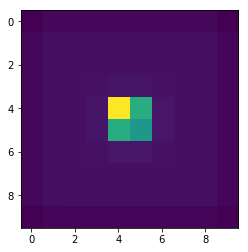

In [51]:
positions = np.arange(300, 2000, 20000)
offset = 0

fittedSigmaPixel = np.array([])
fittedSigmaSubPixel = np.array([])

for position in positions:
    
    print(position)
    
    sim["SubField/ZeroPointRow"] = position - dim // 2
    sim["SubField/ZeroPointColumn"] = position - dim // 2
        
    sim.createStarCatalogFileFromPixelCoordinates(np.array([position + offset]), np.array([position + offset]), np.array([12.5]), np.array([1]), starCatalogFilename)
    
    output = sim.run(removeOutputFile = True)
    image = output.getImage(0)
    subPixelImage = output.getSubPixelImage(0)
    
    image = image * 1000
    subPixelImage = subPixelImage * 1000
    sigma = (position + 0.5) / 1000.0 * 1.5
    print("Sigma:", sigma)
    
    params = fitGaussian2D(image, np.max(image), dim / 2, dim / 2, sigma, sigma, subtractConstant = True)
    fittedSigmaPixel = np.append(fittedSigmaPixel, params[3])
    print("Fit:", params[3])
    
    params = fitGaussian2D(subPixelImage, np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    fittedSigmaSubPixel = np.append(fittedSigmaSubPixel, params[3] / numSubPixels)
    print("Fit:", params[3] / numSubPixels)
    print("Position:", params[1] / numSubPixels, params[2] / numSubPixels)
    
    plt.imshow(image)

10
128
1280
35392720.0 5.0 5.0 0.45075 0.45075
173468.86 640.0 640.0 57.696 57.696
0.0
0.0


NameError: name 'psf' is not defined

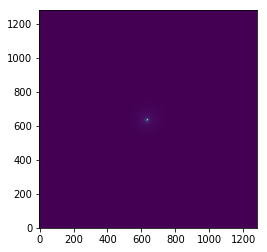

In [52]:
plt.imshow(subPixelImage)
plt.gca().invert_yaxis()
print(dim)
print(numSubPixels)
print(dim * numSubPixels)
print(np.max(image), dim / 2, dim / 2, sigma, sigma)
print(np.max(subPixelImage), dim * numSubPixels / 2, dim * numSubPixels / 2, sigma * numSubPixels, sigma * numSubPixels)

print(np.median(image))
print(np.median(subPixelImage))
print(np.median(psf))

print(np.max(subPixelImage))
print(np.max(psf))

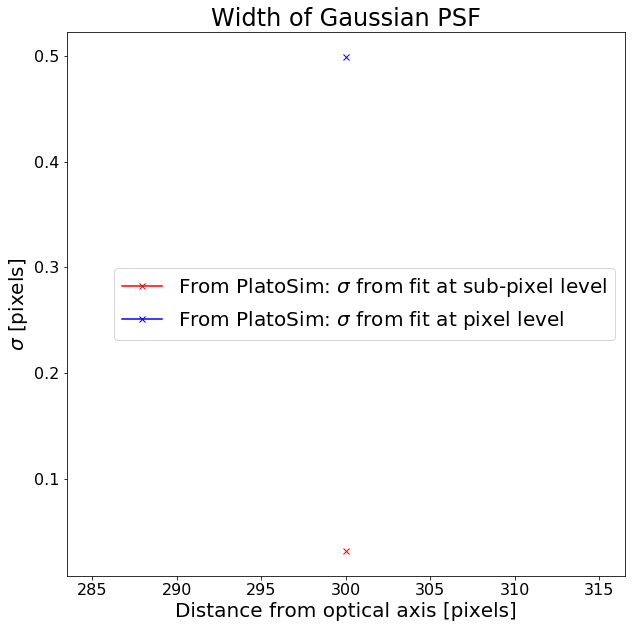

In [53]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



plt.plot(positions, fittedSigmaSubPixel, "rx-", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(positions, fittedSigmaPixel, "bx-", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Distance from optical axis [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

In [54]:
distances = np.array([0, 1414, 2827, 4238, 5647, 7053, 8454, 9850, 11241, 12625, 14001, 15370, 16730, 18081, 18887])
# distances = np.append(distances, distances)
# distances = np.append(distances, distances)
distances = distances / 1000 # [degrees]

plateScaleArcsec = 15
distances = distances / plateScaleArcsec * constants.degree / constants.arcsec # [pixels]

/T6000/ar00000 (Group) '' 0.00075
[0.00075]
/T6000/ar01414 (Group) '' 0.50979
[0.00075    0.03162837]
/T6000/ar02827 (Group) '' 1.01847
[0.00075    0.03162837 0.0786097 ]
/T6000/ar04238 (Group) '' 1.5264300000000004
[ 0.00075     0.03162837  0.0786097  -0.1710149 ]
/T6000/ar05647 (Group) '' 2.03367
[ 0.00075     0.03162837  0.0786097  -0.1710149  -0.21418204]
/T6000/ar07053 (Group) '' 2.53983
[ 0.00075     0.03162837  0.0786097  -0.1710149  -0.21418204  0.2378594 ]
/T6000/ar08454 (Group) '' 3.0441899999999995
[ 0.00075     0.03162837  0.0786097  -0.1710149  -0.21418204  0.2378594
  0.25093731]
/T6000/ar09850 (Group) '' 3.5467499999999994
[ 0.00075     0.03162837  0.0786097  -0.1710149  -0.21418204  0.2378594
  0.25093731 -0.27360713]
/T6000/ar11241 (Group) '' 4.047509999999999
[ 0.00075     0.03162837  0.0786097  -0.1710149  -0.21418204  0.2378594
  0.25093731 -0.27360713  0.31833101]
/T6000/ar12625 (Group) '' 4.54575
[ 0.00075     0.03162837  0.0786097  -0.1710149  -0.21418204  0.2378

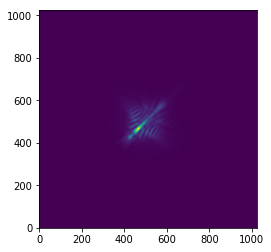

In [58]:
filename = os.environ["PLATO_PROJECT_HOME"] + "/" + sim["PSF/MappedFromFile/Filename"]
psfFile = tables.open_file(filename)
children = psfFile.root.T6000

dim = 1024
fittedSigmaSubPixelPsf = np.array([])

index = 0

# positions = np.sqrt(np.power(positions, 2) * 2)

# plt.plot(positions, positions / 1000.0 * 1.5)

for child in children:
    sigma = (distances[index] + 0.5) / 1000.0 * 1.5
    index += 1
    print(child, sigma)
    psf = np.array(child.az0) * 1000
    params = fitGaussian2D(psf, np.max(psf), dim / 2, dim / 2, sigma * numSubPixels, sigma * numSubPixels, subtractConstant = True)
    fittedSigmaSubPixelPsf = np.append(fittedSigmaSubPixelPsf, params[3]) 
    print(fittedSigmaSubPixelPsf / numSubPixels)
    
    plt.imshow(psf)
    plt.gca().invert_yaxis()

fittedSigmaSubPixelPsf = fittedSigmaSubPixelPsf / numSubPixels  

In [ ]:
plt.plot(distances, fittedSigmaPixel)

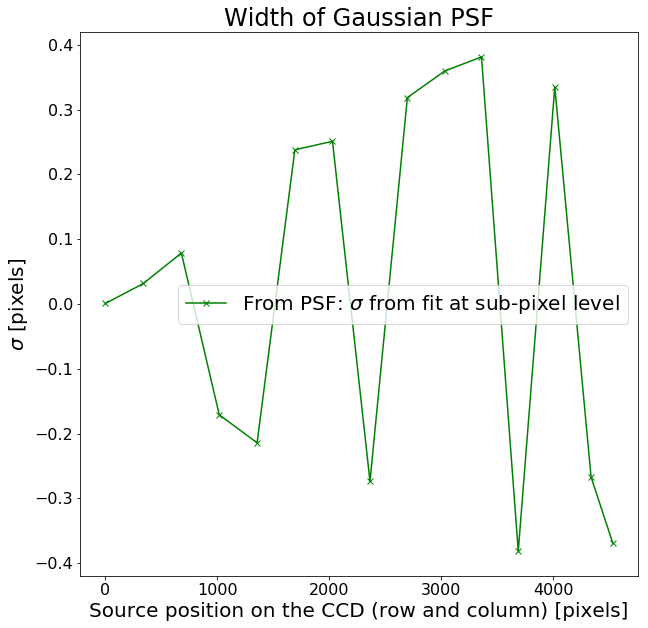

In [56]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)

plt.plot(distances, fittedSigmaSubPixelPsf, "gx-", label = "From PSF: $\\sigma$ from fit at sub-pixel level")

########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position on the CCD (row and column) [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)

ValueError: x and y must have same first dimension, but have shapes (9,) and (1,)

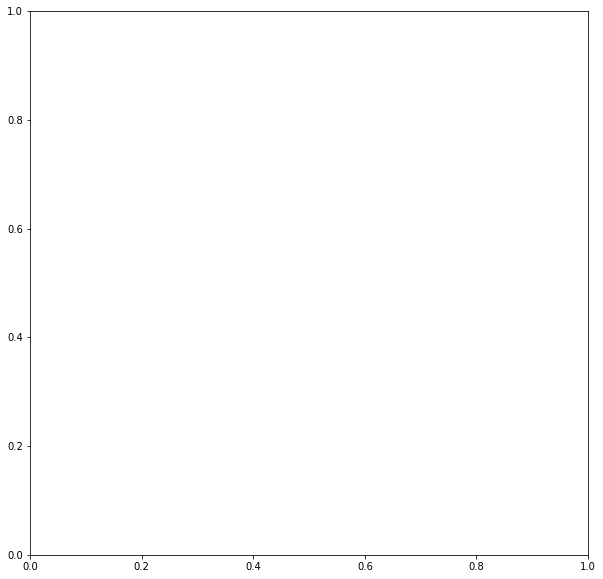

In [57]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)

positions = np.arange(250, 2000, 200)
positions = np.sqrt(np.power(positions, 2) * 2)


plt.plot(positions, fittedSigmaSubPixel, "rx-", label = "From PlatoSim: $\\sigma$ from fit at sub-pixel level")
plt.plot(positions, fittedSigmaPixel, "bx-", label = "From PlatoSim: $\\sigma$ from fit at pixel level")

# a = distances.argsort()
plt.plot(distances, fittedSigmaSubPixelPsf, "gx-", label = "From PSF: $\\sigma$ from fit at sub-pixel level")

########
# Layout
########

plt.title("Width of Gaussian PSF", fontsize = 24)
plt.xlabel("Source position on the CCD (row and column) [pixels]", fontsize = 20)
plt.ylabel("$\\sigma$ [pixels]", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlim([0,4510])

-2167.0127
63260.62


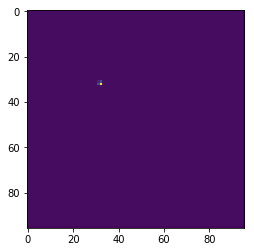

In [26]:
im = output.getSubPixelImage(0)
# im = output.getImagette(1, 0, radius=20)
# im = im - np.min(im)
# im = im / np.sum(im) *  np.max(psf)
d = 60 * numSubPixels
im = image[dim // 2 -  d:dim // 2 + d, dim // 2 -  d:dim // 2 + d]
# im = im - np.min(im)
# im = im / im[512, 512] *  psf[512, 512]
print(np.min(im))
print(np.max(im))

# im[512, 512]
plt.imshow(im)
# plt.imshow(output.getSubPixelImage(0))

In [ ]:
psf = np.array(child.az0)
plt.imshow(psf)
plt.gca().invert_yaxis()

print(np.min(psf))
print(np.max(psf))
psf[512, 512]

In [ ]:
psf = np.array(child.az90)
plt.imshow(psf)
plt.gca().invert_yaxis()

In [ ]:
psf = np.array(child.az180)
plt.imshow(psf)
plt.gca().invert_yaxis()

In [ ]:
psf = np.array(child.az270)
plt.imshow(psf)
plt.gca().invert_yaxis()

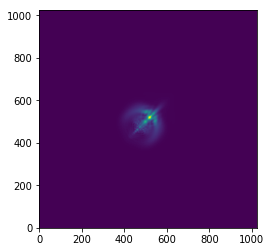

In [83]:
# : "rebinnedPSFpixel", "rebinnedPSFsubPixel", or "rotatedPSF"
plt.imshow(output.getPsf("rotatedPSF"))
plt.gca().invert_yaxis()